In [5]:
!cp -r "/content/drive/MyDrive/EEG_FEATURE" /content/

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import numpy as np
# Load your data
print("Loading data files...")
plv_features = np.load("/content/EEG_FEATURE/plv_features.npy")
cov_features = np.load("/content/EEG_FEATURE/cov_features.npy")
reaction_times = np.load("/content/EEG_FEATURE/Reaction.npy")

print(f"PLV features shape: {plv_features.shape}")
print(f"Covariance features shape: {cov_features.shape}")
print(f"Reaction times shape: {reaction_times.shape}")

Loading data files...
PLV features shape: (81362, 435)
Covariance features shape: (81362, 435)
Reaction times shape: (81362,)


In [8]:
# Ensure numpy itself is not overwritten.
import numpy as np

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split


# Import GPU-accelerated libraries (if available)
try:
    # RAPIDS libraries for GPU acceleration
    import cudf
    import cuml
    from cuml.preprocessing import StandardScaler
    from cuml.ensemble import RandomForestRegressor
    from cuml.svm import SVR
    from cuml.linear_model import LinearRegression
    from cuml.neighbors import KNeighborsRegressor  # GPU-based KNN

    print("GPU acceleration enabled with RAPIDS!")
    USE_GPU = True

except ImportError:
    # Fall back to CPU libraries
    print("RAPIDS not available. Using CPU implementation.")
    from sklearn.preprocessing import StandardScaler
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    from sklearn.svm import SVR
    from sklearn.linear_model import LinearRegression
    from sklearn.neighbors import KNeighborsRegressor
    USE_GPU = False



# Concatenate features
print("Preparing combined features...")
X = np.concatenate((plv_features, cov_features), axis=1)
print(f"Combined features shape: {X.shape}")

# Split data
print("Splitting data into train/test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, reaction_times, test_size=0.3, random_state=42)

# Scale features
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to GPU format if using RAPIDS
if USE_GPU:
    try:
        import cupy as cp
        X_train_scaled = cp.array(X_train_scaled)
        X_test_scaled = cp.array(X_test_scaled)
        y_train = cp.array(y_train)
        y_test = cp.array(y_test)
    except ImportError:
        pass

# Define models to test (Removed XGBoost, Elastic Net, and Ridge Regression)
if USE_GPU:
    models = {
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Linear Regression": LinearRegression(),
        "K-Nearest Neighbors": KNeighborsRegressor(),
        "Support Vector Regression": SVR(kernel='rbf')
    }
else:
    models = {
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
        "Linear Regression": LinearRegression(),
        "K-Nearest Neighbors": KNeighborsRegressor(),
        "Support Vector Regression": SVR(kernel='rbf')
    }

# Train and evaluate each model
results = {}
print("Training and evaluating models:")
for name, model in tqdm(models.items(), desc="Models"):
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Convert back to CPU if necessary for sklearn metrics
    if USE_GPU:
        try:
            y_pred_np = y_pred.get() if hasattr(y_pred, 'get') else y_pred
            y_test_np = y_test.get() if hasattr(y_test, 'get') else y_test
        except AttributeError:
            y_pred_np = y_pred
            y_test_np = y_test
    else:
        y_pred_np = y_pred
        y_test_np = y_test

    # Calculate metrics
    mse = mean_squared_error(y_test_np, y_pred_np)
    mae = mean_absolute_error(y_test_np, y_pred_np)
    rmse = np.sqrt(mse)

    print(f"  MSE: {mse:.6f}")
    print(f"  MAE: {mae:.6f}")
    print(f"  RMSE: {rmse:.6f}")

    results[name] = {
        "model": model,
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "predictions": y_pred_np
    }

# Display results in a table
import pandas as pd
df_test_results = pd.DataFrame.from_dict(results, orient='index')[["mse", "rmse", "mae"]]
print("\nTest Set Evaluation:")
print(df_test_results)


GPU acceleration enabled with RAPIDS!
Preparing combined features...
Combined features shape: (81362, 870)
Splitting data into train/test sets...
Scaling features...
Training and evaluating models:


Models:   0%|          | 0/4 [00:00<?, ?it/s]


Training Random Forest...
  MSE: 0.720443
  MAE: 0.576900
  RMSE: 0.848789

Training Linear Regression...
  MSE: 0.737842
  MAE: 0.574110
  RMSE: 0.858977

Training K-Nearest Neighbors...
  MSE: 0.867460
  MAE: 0.613461
  RMSE: 0.931376

Training Support Vector Regression...
  MSE: 0.836353
  MAE: 0.449209
  RMSE: 0.914523

Test Set Evaluation:
                                mse      rmse       mae
Random Forest              0.720443  0.848789  0.576900
Linear Regression          0.737842  0.858977  0.574110
K-Nearest Neighbors        0.867460  0.931376  0.613461
Support Vector Regression  0.836353  0.914523  0.449209


In [9]:
import pandas as pd

# Create a DataFrame from the results dictionary, selecting the desired metrics
df_test_results = pd.DataFrame.from_dict(results, orient='index')[["mse", "rmse", "mae"]]

# Print the table
print("\nTest Set Evaluation:")
print(df_test_results)



Test Set Evaluation:
                                mse      rmse       mae
Random Forest              0.720443  0.848789  0.576900
Linear Regression          0.737842  0.858977  0.574110
K-Nearest Neighbors        0.867460  0.931376  0.613461
Support Vector Regression  0.836353  0.914523  0.449209


In [10]:
# Select a few trials for inspection
sample_size = 10  # Number of trials to display

# Assuming 'y_test' contains your actual target values
# Convert y_test to NumPy array if it's a CuPy array
sample_actual = y_test.get()[:sample_size] if hasattr(y_test, 'get') else y_test[:sample_size]

# Assuming you want to compare with predictions from a specific model
# Replace 'Random Forest' with the actual model name if needed
model_name = 'Random Forest'
# Convert predictions to NumPy array if it's a CuPy array
sample_predicted = results[model_name]['predictions'].get()[:sample_size] if hasattr(results[model_name]['predictions'], 'get') else results[model_name]['predictions'][:sample_size]

# Create a DataFrame
comparison_df = pd.DataFrame({
    "Actual Reaction Time (ms)": sample_actual,
    "Predicted Reaction Time (ms)": sample_predicted
})

# Print table for quick review
print("\nSample Comparison: Actual vs Predicted Reaction Times")
print(comparison_df)


Sample Comparison: Actual vs Predicted Reaction Times
   Actual Reaction Time (ms)  Predicted Reaction Time (ms)
0                      0.652                      0.223989
1                      0.000                      0.540730
2                      0.594                      0.419612
3                      0.590                      0.259046
4                      0.000                      0.344833
5                      0.000                      0.262175
6                      0.780                      0.248470
7                      0.000                      0.331843
8                      0.000                      0.243262
9                      0.000                      0.228335


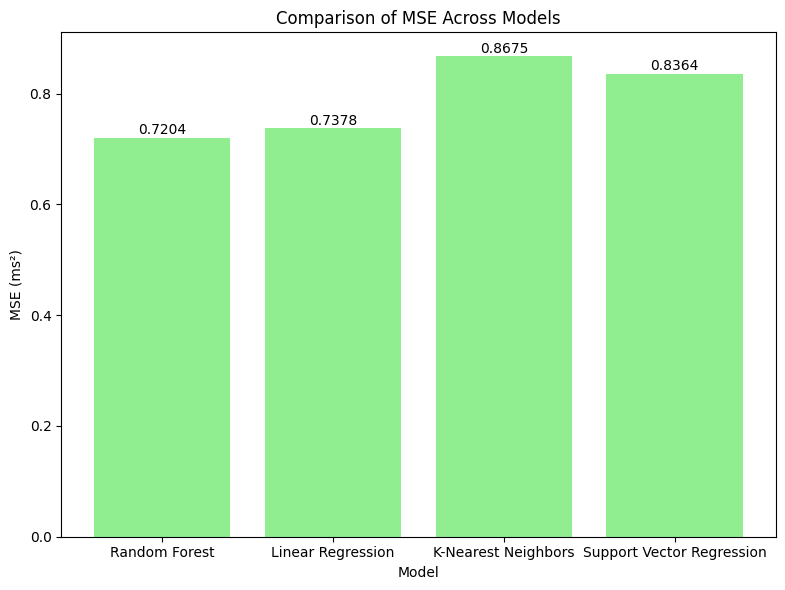

In [11]:
import matplotlib.pyplot as plt

# Extract the MSE values and corresponding model names from the results DataFrame.
mse_values = df_test_results["mse"]
model_names = df_test_results.index

# Create a bar chart for MSE values.
plt.figure(figsize=(8, 6))
bars = plt.bar(model_names, mse_values, color='lightgreen')

plt.xlabel("Model")
plt.ylabel("MSE (ms²)")
plt.title("Comparison of MSE Across Models")

# Annotate each bar with its corresponding MSE value.
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.001, f"{height:.4f}",
             ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [14]:
import cupy as cp  # GPU accelerated NumPy alternative
import pandas as pd
from cuml.ensemble import RandomForestRegressor  # RAPIDS GPU-accelerated Random Forest
from cuml.metrics import mean_squared_error  # RAPIDS GPU metrics
from cuml.preprocessing import StandardScaler  # RAPIDS GPU scaler
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

print("GPU acceleration enabled with RAPIDS!")


# Define feature sets
# Convert NumPy arrays to CuPy arrays
X_covariance = cp.asarray(cov_features)
X_plv = cp.asarray(plv_features)
X_combined = cp.concatenate((X_plv, X_covariance), axis=1)

def evaluate_model_gpu(X, y):
    """
    Splits the data, scales features, trains a GPU-based Random Forest regressor,
    and computes MSE, RMSE, and MAE on the GPU.
    """
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42)

    # Scale features using RAPIDS
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train a GPU-based Random Forest model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predict on test set
    y_pred = model.predict(X_test_scaled)

    # Compute metrics directly on GPU
    mse = mean_squared_error(y_test, y_pred)
    rmse = cp.sqrt(mse)

    # Convert GPU arrays back to CPU for MAE calculation
    mae = mean_absolute_error(cp.asnumpy(y_test), cp.asnumpy(y_pred))

    return mse, rmse, mae

# Dictionary to store performance results
performance_metrics = {
    "Feature Set": [],
    "MSE (ms^2)": [],
    "RMSE (ms)": [],
    "MAE (ms)": []
}

# Evaluate on different feature sets
mse_cov, rmse_cov, mae_cov = evaluate_model_gpu(X_covariance, reaction_times)
performance_metrics["Feature Set"].append("Covariance only")
performance_metrics["MSE (ms^2)"].append(float(cp.asnumpy(mse_cov)))
performance_metrics["RMSE (ms)"].append(float(cp.asnumpy(rmse_cov)))
performance_metrics["MAE (ms)"].append(mae_cov)

mse_plv, rmse_plv, mae_plv = evaluate_model_gpu(X_plv, reaction_times)
performance_metrics["Feature Set"].append("PLV only")
performance_metrics["MSE (ms^2)"].append(float(cp.asnumpy(mse_plv)))
performance_metrics["RMSE (ms)"].append(float(cp.asnumpy(rmse_plv)))
performance_metrics["MAE (ms)"].append(mae_plv)

mse_comb, rmse_comb, mae_comb = evaluate_model_gpu(X_combined, reaction_times)
performance_metrics["Feature Set"].append("Covariance + PLV")
performance_metrics["MSE (ms^2)"].append(float(cp.asnumpy(mse_comb)))
performance_metrics["RMSE (ms)"].append(float(cp.asnumpy(rmse_comb)))
performance_metrics["MAE (ms)"].append(mae_comb)

# Convert dictionary to pandas DataFrame
df_performance = pd.DataFrame(performance_metrics)

# Print performance comparison
print("\nGPU-Accelerated Comparison of Model Performance on Different Feature Sets")
print(df_performance)


GPU acceleration enabled with RAPIDS!


/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return init_func(self, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recommended. If n_streams is > 1, results may vary due to stream/thread timing differences, even when random_state is set
  return init_func(self, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/cuml/internals/api_decorators.py:368: UserWarning: For reproducible results in Random Forest Classifier or for almost reproducible results in Random Forest Regressor, n_streams=1 is recomm


GPU-Accelerated Comparison of Model Performance on Different Feature Sets
        Feature Set  MSE (ms^2)  RMSE (ms)  MAE (ms)
0   Covariance only    0.728816   0.853707  0.578883
1          PLV only    0.722371   0.849924  0.575833
2  Covariance + PLV    0.719854   0.848442  0.576721


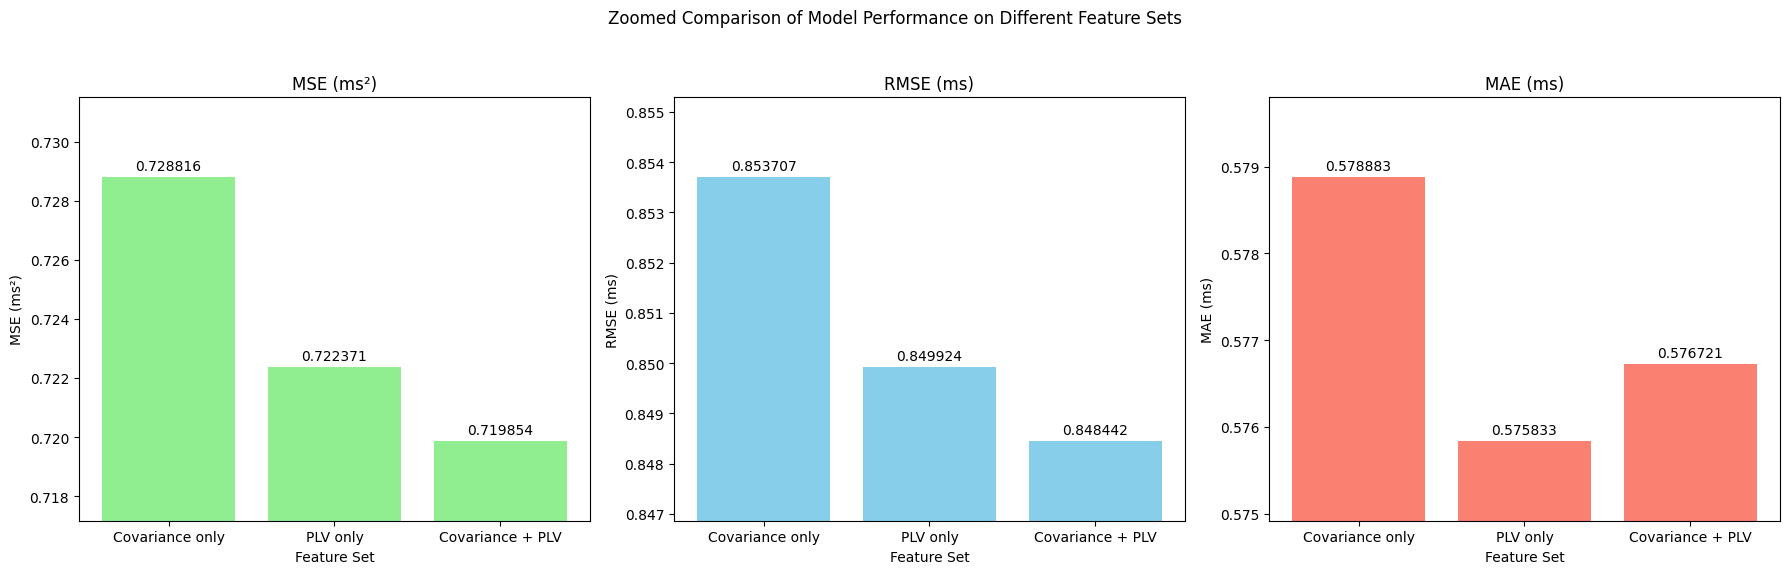

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# MSE values and dynamic y-axis limits:
mse_values = df_performance["MSE (ms^2)"]
min_mse, max_mse = mse_values.min(), mse_values.max()
y_margin_mse = (max_mse - min_mse) * 0.3  # 30% margin

# RMSE values and dynamic y-axis limits:
rmse_values = df_performance["RMSE (ms)"]
min_rmse, max_rmse = rmse_values.min(), rmse_values.max()
y_margin_rmse = (max_rmse - min_rmse) * 0.3  # 30% margin

# MAE values and dynamic y-axis limits:
mae_values = df_performance["MAE (ms)"]
min_mae, max_mae = mae_values.min(), mae_values.max()
y_margin_mae = (max_mae - min_mae) * 0.3  # 30% margin

# Create a figure with three subplots for MSE, RMSE, and MAE.
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# -----------------------------
# Bar Chart for MSE (ms^2)
# -----------------------------
bars_mse = axs[0].bar(df_performance["Feature Set"], mse_values, color='lightgreen')
axs[0].set_title("MSE (ms²)")
axs[0].set_xlabel("Feature Set")
axs[0].set_ylabel("MSE (ms²)")
axs[0].set_ylim(min_mse - y_margin_mse, max_mse + y_margin_mse)
for bar in bars_mse:
    h = bar.get_height()
    axs[0].text(bar.get_x() + bar.get_width()/2, h + (y_margin_mse * 0.05), f"{h:.6f}",
                ha='center', va='bottom')

# -----------------------------
# Bar Chart for RMSE (ms)
# -----------------------------
bars_rmse = axs[1].bar(df_performance["Feature Set"], rmse_values, color='skyblue')
axs[1].set_title("RMSE (ms)")
axs[1].set_xlabel("Feature Set")
axs[1].set_ylabel("RMSE (ms)")
axs[1].set_ylim(min_rmse - y_margin_rmse, max_rmse + y_margin_rmse)
for bar in bars_rmse:
    h = bar.get_height()
    axs[1].text(bar.get_x() + bar.get_width()/2, h + (y_margin_rmse * 0.05), f"{h:.6f}",
                ha='center', va='bottom')

# -----------------------------
# Bar Chart for MAE (ms)
# -----------------------------
bars_mae = axs[2].bar(df_performance["Feature Set"], mae_values, color='salmon')
axs[2].set_title("MAE (ms)")
axs[2].set_xlabel("Feature Set")
axs[2].set_ylabel("MAE (ms)")
axs[2].set_ylim(min_mae - y_margin_mae, max_mae + y_margin_mae)
for bar in bars_mae:
    h = bar.get_height()
    axs[2].text(bar.get_x() + bar.get_width()/2, h + (y_margin_mae * 0.05), f"{h:.6f}",
                ha='center', va='bottom')

plt.suptitle("Zoomed Comparison of Model Performance on Different Feature Sets")
plt.savefig("performance_bar.png")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


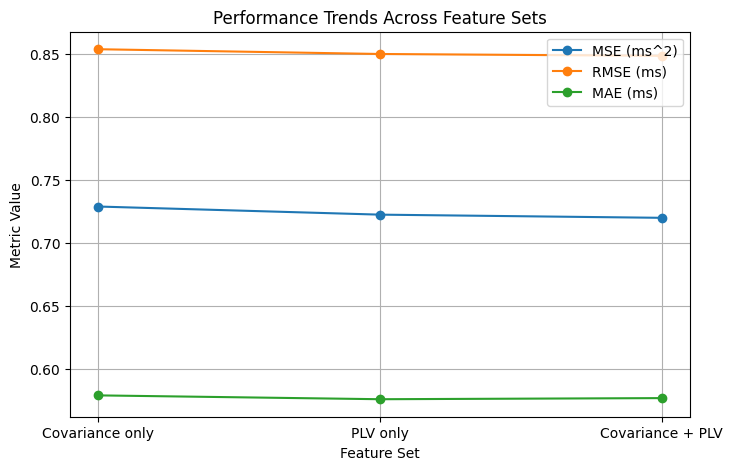

In [16]:
plt.figure(figsize=(8, 5))

for metric in ["MSE (ms^2)", "RMSE (ms)", "MAE (ms)"]:
    plt.plot(df_performance["Feature Set"], df_performance[metric], marker="o", linestyle="-", label=metric)

plt.xlabel("Feature Set")
plt.ylabel("Metric Value")
plt.title("Performance Trends Across Feature Sets")
plt.legend()
plt.grid(True)
plt.show()


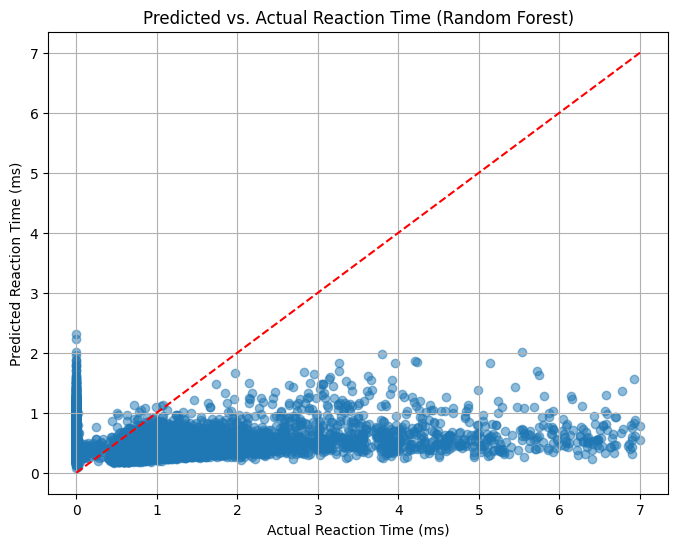

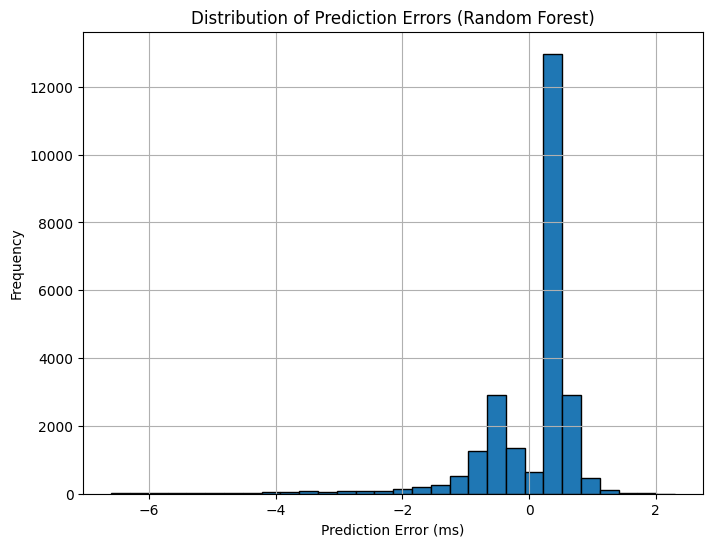

In [18]:
import matplotlib.pyplot as plt

# Assuming 'results' dictionary and 'y_test' are available from previous code

# Extract actual and predicted values for the Random Forest model
y_test_np = y_test.get() if hasattr(y_test, 'get') else y_test
y_pred_rf = results['Random Forest']['predictions']

# Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_np, y_pred_rf, alpha=0.5)
plt.plot([min(y_test_np), max(y_test_np)], [min(y_test_np), max(y_test_np)], color='red', linestyle='--') # Diagonal line
plt.xlabel("Actual Reaction Time (ms)")
plt.ylabel("Predicted Reaction Time (ms)")
plt.title("Predicted vs. Actual Reaction Time (Random Forest)")
plt.grid(True)
plt.show()

# Create the error distribution histogram
errors = y_pred_rf - y_test_np
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=30, edgecolor='black')
plt.xlabel("Prediction Error (ms)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors (Random Forest)")
plt.grid(True)
plt.show()


